In [2]:
#import
import os
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import fiona
import rasterio.mask
import rioxarray as rio
from datetime import datetime

In [1]:
# set directory
dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405_v2"
Task_number = 1

In [59]:
lidar = glob.glob(os.path.join(dir, "lidar","*.tif"))

# Split by underscore and pick the part that looks like a date
parts = os.path.basename(lidar[0]).split("_")
for part in parts:
    if part.isdigit() and len(part) == 8:
        date_str = part
        #break

        date_obj = datetime.strptime(date_str, "%Y%m%d")

with rasterio.open(lidar[0]) as src:
    data = src.read(1, masked=True)
    profile = src.profile
    profile.update(dtype=rasterio.float32, nodata=-9999)
    outfile = os.path.join(dir, "lidar", "lidar_"+date_str+".tif")
#Replace NaNs with -9999
data_filled = np.where(np.isnan(data), -9999, data)

# Write the new raster
with rasterio.open(outfile, "w", **profile) as dst:
    dst.write(data_filled.astype("float32"), 1)
    
lidar_raster = outfile

In [60]:
if Task_number == 1:
    modeled = os.path.join(dir, "modeled/Task1")
else: 
    modeled = os.path.join(dir, "modeled/Task2")

In [61]:

HMS_EB = glob.glob(os.path.join(modeled, "*EB_snow_depth*.tif"))[0]
HMS_TI = glob.glob(os.path.join(modeled, "*TI_snow_depth*.tif"))[0]

with rasterio.open(HMS_EB) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
    
    # Replace NaN with NoData value
    nodata_val = -9999
    out_raster = np.where(np.isnan(out_raster), nodata_val, out_raster)
    
    out_path = os.path.join(modeled, "HMS_EB_inches.tif")
    profile = src.profile
    profile.update(dtype=rasterio.float32, nodata=nodata_val)
    
    with rasterio.open(out_path, "w", **profile) as dest:
        dest.write(out_raster.astype("float32"), 1)

with rasterio.open(HMS_TI) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
    
    # Replace NaN with NoData value
    nodata_val = -9999
    out_raster = np.where(np.isnan(out_raster), nodata_val, out_raster)
    
    out_path = os.path.join(modeled, "HMS_TI_inches.tif")
    profile = src.profile
    profile.update(dtype=rasterio.float32, nodata=nodata_val)
    
    with rasterio.open(out_path, "w", **profile) as dest:
        dest.write(out_raster.astype("float32"), 1)


In [62]:
rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
}

print(rasters)

{'HMS_EB': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2024/20240315\\modeled\\HMS_EB_inches.tif'], 'HMS_TI': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2024/20240315\\modeled\\HMS_TI_inches.tif'], 'iSnobal': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2024/20240315\\modeled\\thickness_2024-03-15T23_00_00.tif'], 'SnowModel': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2024/20240315\\modeled\\snod_666_03-15-2024_12.tif']}


In [63]:
MCS = os.path.join(dir, "MCS_outline/basin_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [64]:
if Task_number == 1:
    out_dir = os.path.join(dir, "outputs/task1/")
else:
    out_dir = os.path.join(dir, "outputs/task2/")
    
rasters_dir = os.path.join(out_dir, "rasters/")
figs_dir = os.path.join(out_dir, "figs/")
    
stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
            profile = src.profile

        # Include model in output filename
        out_name = f"{model}_basin_clip.tif"
        out_path = os.path.join(out_dir,"rasters/", out_name)

        with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_image)

# Compute statistics
        data = out_image  # 1 band raster, extract 2D array
        mask = (data == -9999)
        data_masked = np.ma.array(data, mask=mask)  # mask nodata

        raster_stats = {
            "file": out_name,
            "model": model,
            "min": data_masked.min(),
            "mean": data_masked.mean(),
            "max": data_masked.max(),
            "zeros": np.sum(data_masked == 0)
        }
        
        stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(figs_dir, "basin_stats.csv")
stats_df.to_csv(stats_csv, index=False)


In [5]:
# import os
# 
# dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/template/"
# 
# Task_number = 1
# 
# if Task_number == 1:
#     out_dir = os.path.join(dir, "outputs/task1/")
# else:
#     out_dir = os.path.join(dir, "outputs/task2/")
#     
# out_name = "test"
# 
# out_path = os.path.join(out_dir,"rasters/", out_name)
# 
# print(out_path)


C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/template/outputs/task1/rasters/test


In [77]:


rasters = {
    "HMS Energy Balance": glob.glob(os.path.join(rasters_dir, "HMS_EB_basin_clip.tif")),
    "HMS Temperature Index": glob.glob(os.path.join(rasters_dir, "HMS_TI_basin_clip.tif")),
    "iSnobal": glob.glob(os.path.join(rasters_dir, "iSnobal_basin_clip.tif")),
    "SnowModel": glob.glob(os.path.join(rasters_dir, "SnowModel_basin_clip.tif")),
}

In [78]:
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            print(src.crs)

EPSG:32611
EPSG:32611
EPSG:32611
None


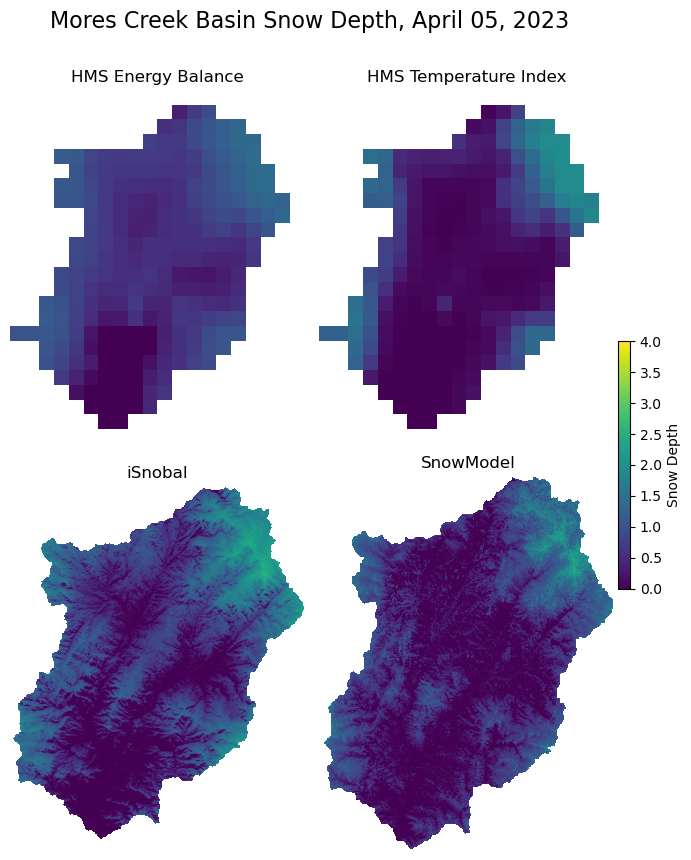

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(8, 10))
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster_list) in enumerate(rasters.items()):
    raster_path = raster_list[0] 
    
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].axis("off")

# Add colorbar
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, label="Snow Depth")
fig.suptitle(f"Mores Creek Basin Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.savefig(os.path.join(figs_dir, "Basin_models.png"), dpi=300, bbox_inches="tight")

plt.show()



In [67]:
dfs = []

for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

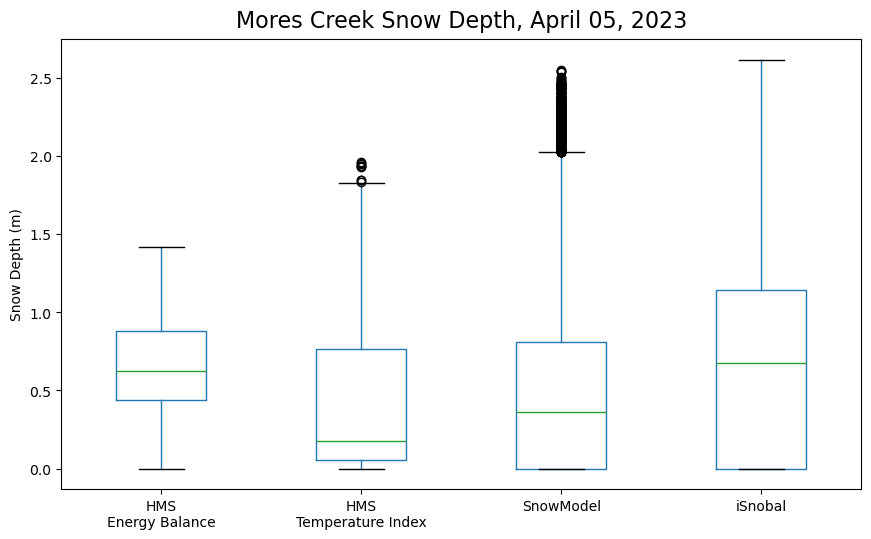

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

# Suppose your DataFrame has a column "Model" with long names
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove pandas' default title
ax.set_title("")

# Create multi-line labels by inserting '\n'
labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = []
for lbl in labels:
    if len(lbl) > 12:  # arbitrarily split long labels
        # split in half
        mid = len(lbl) // 2
        # find nearest space to split
        space_idx = lbl.rfind(" ", 0, mid)
        if space_idx == -1:
            space_idx = mid
        lbl = lbl[:space_idx] + "\n" + lbl[space_idx:].strip()
    new_labels.append(lbl)

ax.set_xticklabels(new_labels)

# Figure-level title
fig.suptitle(f"Mores Creek Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)

ax.set_ylabel("Snow Depth (m)")
ax.set_xlabel("")

#plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(figs_dir, "basin_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


In [76]:
MCS = os.path.join(dir, "MCS_outline/MCS_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    #"SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
    "LiDAR": [lidar_raster]
}

AttributeError: 'list' object has no attribute 'crs'

In [73]:
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            print(src.crs)

EPSG:32611
EPSG:32611
None
EPSG:32611


In [75]:
stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
            out_meta = src.meta.copy()

        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })

        # Include model in output filename
        out_name = f"{model}_MCS_clip.tif"
        out_path = os.path.join(rasters_dir, out_name)

        with rasterio.open(out_path, "w", **out_meta) as dest:
            dest.write(out_image)

# Compute statistics
        data = out_image[0]  # 1 band raster, extract 2D array
        mask = (data == -9999)
        data_masked = np.ma.array(data, mask=mask)  # mask nodata

        raster_stats = {
            "file": out_name,
            "model": model,
            "min": data_masked.min(),
            "mean": data_masked.mean(),
            "max": data_masked.max(),
            "zeros": np.sum(data_masked == 0)
        }
        
        stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(figs_dir, "MCS_stats.csv")
stats_df.to_csv(stats_csv, index=False)


ValueError: Input shapes do not overlap raster.

In [25]:
rasters = {
    "HMS Energy Balance": os.path.join(rasters_dir, "HMS_EB_MCS_clip.tif"),
    "HMS Temperature Index": os.path.join(rasters_dir, "HMS_TI_MCS_clip.tif"),
    "iSnobal": os.path.join(rasters_dir, "iSnobal_MCS_clip.tif"),
    "SnowModel": os.path.join(rasters_dir, "SnowModel_MCS_clip.tif"),
    "LiDAR": os.path.join(rasters_dir, "LiDAR_MCS_clip.tif")
}

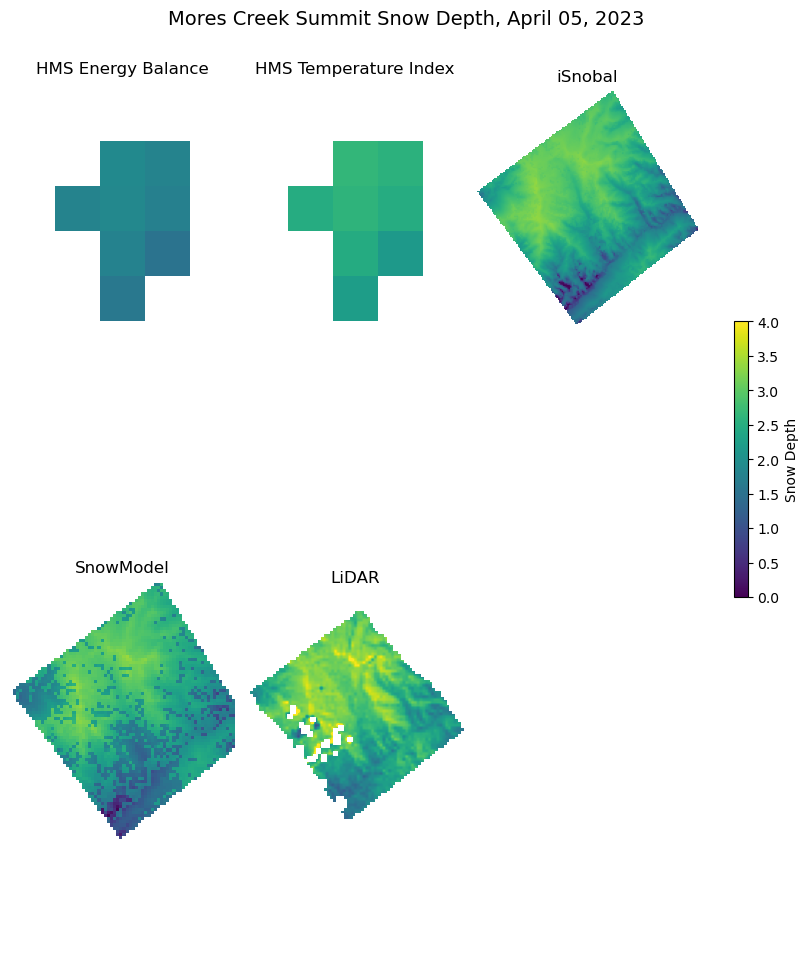

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(8, 10),constrained_layout=True)
axes = axes.flatten()  # flatten to 1D array for easy looping


axes = axes.flatten()

for i, (model, raster_path) in enumerate(rasters.items()):
    #raster_path = raster_list[0] 
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0) #aspect="auto")
    axes[i].set_title(model)
    axes[i].axis("off")

axes[-1].axis("off")
# Add colorbar
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, label="Snow Depth")
fig.suptitle(f"Mores Creek Summit Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=14,  y=0.95)

# fig.subplots_adjust(
#     #wspace=.01,
#     hspace=0.01,
#     right=0.85
#     #top=0.90
# )

plt.savefig(os.path.join(figs_dir, "MCS_models.png"), dpi=300, bbox_inches="tight")

plt.show()



In [41]:
dfs = []

for model, raster in rasters.items():
    #for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

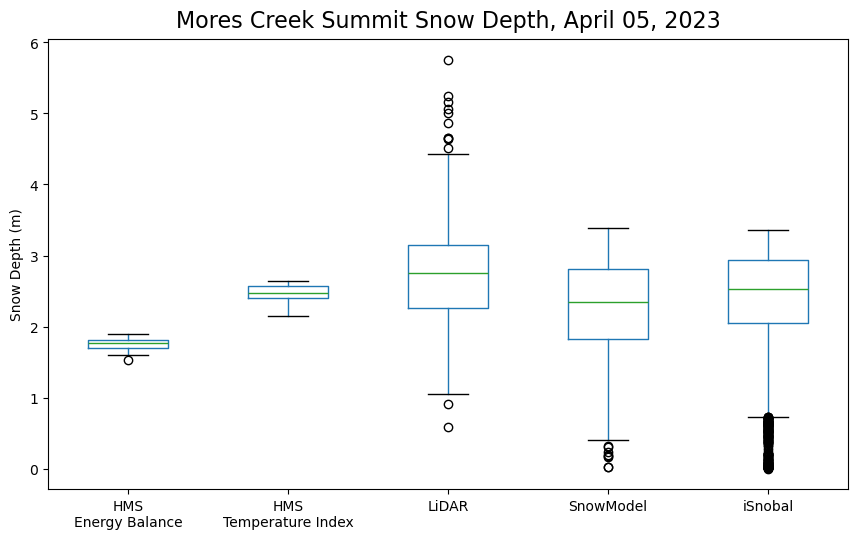

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

# Suppose your DataFrame has a column "Model" with long names
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove pandas' default title
ax.set_title("")

# Create multi-line labels by inserting '\n'
labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = []
for lbl in labels:
    if len(lbl) > 12:  # arbitrarily split long labels
        # split in half
        mid = len(lbl) // 2
        # find nearest space to split
        space_idx = lbl.rfind(" ", 0, mid)
        if space_idx == -1:
            space_idx = mid
        lbl = lbl[:space_idx] + "\n" + lbl[space_idx:].strip()
    new_labels.append(lbl)

ax.set_xticklabels(new_labels)

# Figure-level title
fig.suptitle(f"Mores Creek Summit Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)

ax.set_ylabel("Snow Depth (m)")
ax.set_xlabel("")

#plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(figs_dir, "MCS_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


In [43]:
del rasters["LiDAR"]
lidar = os.path.join(rasters_dir, "LiDAR_MCS_clip.tif")

In [404]:
# Read LiDAR separately
#https://rasterio.readthedocs.io/en/stable/topics/reproject.html
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.warp import reproject, Resampling


with rasterio.open(lidar) as src:
    lidar_data = src.read(1, masked=True)
    profile = src.profile                 # for writing outputs
    lidar_crs = src.crs
    lidar_transform = src.transform  # True where LiDAR is masked


In [410]:
for model, raster_path in rasters.items():
    with rasterio.open(raster_path) as src:
        model_data = src.read(1, masked=True)
        model_transform = src.transform
        model_crs = src.crs

        # Assign CRS if missing
        if model_crs is None:
            model_crs = lidar_crs
            print(f"Assigned CRS {model_crs} to {model} because it was missing.")

        # Prepare array for reprojected data
        reprojected_model = np.empty(lidar_data.shape, dtype=np.float32)

        # Reproject/resample model to match LiDAR
        reproject(
            source=model_data,
            destination=reprojected_model,
            src_transform=model_transform,
            src_crs=model_crs,
            dst_transform=lidar_transform,
            dst_crs=lidar_crs,
            resampling=Resampling.bilinear
        )

        # Mask wherever either raster is NaN / masked
        combined_mask = (lidar_data.data == -9999) | (reprojected_model == -9999)
        model_masked = np.ma.array(reprojected_model, mask=combined_mask)
        lidar_masked = np.ma.array(lidar_data, mask=combined_mask)

        # Compute difference
        diff_data = lidar_masked - model_masked

        # Write difference raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, compress="lzw")

        # Write difference raster
        out_path = os.path.join(rasters_dir, f"{model.replace(' ', '_')}_lidar_diff.tif")
        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(diff_data.filled(np.nan).astype(np.float32), 1)


Assigned CRS EPSG:32611 to SnowModel because it was missing.
